# RPS Experiment Results Analysis

## IMPORTANT: Model Categories

This analysis separates models into two distinct categories:

### 1. Audio Enhancement Models (produce speech audio)
- DCUNet baseline
- DCUNet + RPS conditioning
- DCUNet + RPS + PredRPS (auxiliary RPS prediction head)
- DCCRN baseline
- DCCRN + RPS conditioning
- DCCRN + RPS + PredRPS

**Metrics**: SI-SDR, ESTOI, PESQ

### 2. RPS-Only Models (predict rotor speeds only, NO audio output)
- **RPSPredictor (Standalone)**: Simple convolutional predictor on log-magnitude spectrograms, trained with dedicated script
- **RPSPredictor (Postdoc)**: Same architecture, trained via postdoc with train.py
- **DCUNet RPS-Only**: DCUNet encoder + RPSPredictionHead, trained on RPS loss only
- **DCCRN RPS-Only**: DCCRN encoder + RPSPredictionHead, trained on RPS loss only

**Metrics**: RPS-MSE, RPS-MAE, R² (coefficient of determination)

⚠️ **RPS-only models do NOT produce audio output. They are NOT comparable with audio models on speech metrics.**

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Results directories
EVAL_DIR = Path("../results/evaluation")
REMOTE_RESULTS = Path("../results")

print(f"Evaluation dir: {EVAL_DIR.exists()}")

Evaluation dir: True


---

# Part 1: Audio Enhancement Models

## Load Evaluation Results

In [2]:
# Load existing per-SNR comparison CSV (from previous analysis)
per_snr_path = EVAL_DIR / "dregon_per_snr_comparison.csv"
if per_snr_path.exists():
    per_snr_df = pd.read_csv(per_snr_path)
    print("Loaded per-SNR comparison data")
    display(per_snr_df.head(10))
else:
    print("Per-SNR comparison not found")
    per_snr_df = None

Loaded per-SNR comparison data


,model,snr_level,n_samples,si_sdr,estoi,pesq
0,DCUNet baseline,-30,46,-34.3543,0.0318,1.1108
1,DCUNet baseline,-25,83,-30.2504,0.0342,1.1562
2,DCUNet baseline,-20,84,-17.0350,0.0980,1.0743
3,DCUNet baseline,-15,110,-6.1358,0.1748,1.0505
4,DCUNet baseline,-10,108,-0.5888,0.2806,1.0842
5,DCUNet baseline,-5,108,3.2807,0.4465,1.2468
6,DCUNet baseline,0,61,5.1277,0.5530,1.3626
7,DCUNet baseline,Overall,600,-9.3224,0.2401,1.1462
8,DCUNet+RPS,-30,46,-28.3316,0.0383,1.1299
9,DCUNet+RPS,-25,83,-23.7074,0.0355,1.1385


In [3]:
# Define audio model categories
audio_models = {
    'DCUNet baseline': {
        'display_name': 'DCUNet\nBaseline',
        'color': '#1f77b4',
    },
    'DCUNet+RPS': {
        'display_name': 'DCUNet\n+RPS',
        'color': '#2ca02c',
    },
    'DCUNet+RPS+PredRPS*': {
        'display_name': 'DCUNet\n+RPS+PredRPS*',
        'color': '#ff7f0e',
    },
    'DCCRN baseline': {
        'display_name': 'DCCRN\nBaseline',
        'color': '#d62728',
    },
    'DCCRN+RPS': {
        'display_name': 'DCCRN\n+RPS',
        'color': '#9467bd',
    },
    'DCCRN+RPS+PredRPS*': {
        'display_name': 'DCCRN\n+RPS+PredRPS*',
        'color': '#8c564b',
    },
}

# Filter for audio models only
if per_snr_df is not None:
    audio_df = per_snr_df[per_snr_df['model'].isin(audio_models.keys())].copy()
    print(f"Audio models: {audio_df['model'].unique().tolist()}")

Audio models: ['DCUNet baseline', 'DCUNet+RPS', 'DCUNet+RPS+PredRPS*', 'DCCRN baseline', 'DCCRN+RPS', 'DCCRN+RPS+PredRPS*']


In [4]:
# Summary table: Overall metrics for audio models
if per_snr_df is not None:
    audio_overall = per_snr_df[
        (per_snr_df['model'].isin(audio_models.keys())) & 
        (per_snr_df['snr_level'] == 'Overall')
    ][['model', 'si_sdr', 'estoi', 'pesq', 'n_samples']]
    
    # Rename columns for display
    audio_overall = audio_overall.rename(columns={
        'si_sdr': 'SI-SDR (dB)',
        'estoi': 'ESTOI',
        'pesq': 'PESQ'
    })
    
    # Format for display
    display(audio_overall.sort_values('SI-SDR (dB)', ascending=False))

,model,SI-SDR (dB),ESTOI,PESQ,n_samples
31,DCCRN baseline,-5.6759,0.2666,1.1246,600
15,DCUNet+RPS,-7.5920,0.2374,1.1379,600
39,DCCRN+RPS,-7.9758,0.2419,1.1369,600
47,DCCRN+RPS+PredRPS*,-8.4733,0.2255,1.1145,600
7,DCUNet baseline,-9.3224,0.2401,1.1462,600
23,DCUNet+RPS+PredRPS*,-25.3389,0.1323,1.3298,600


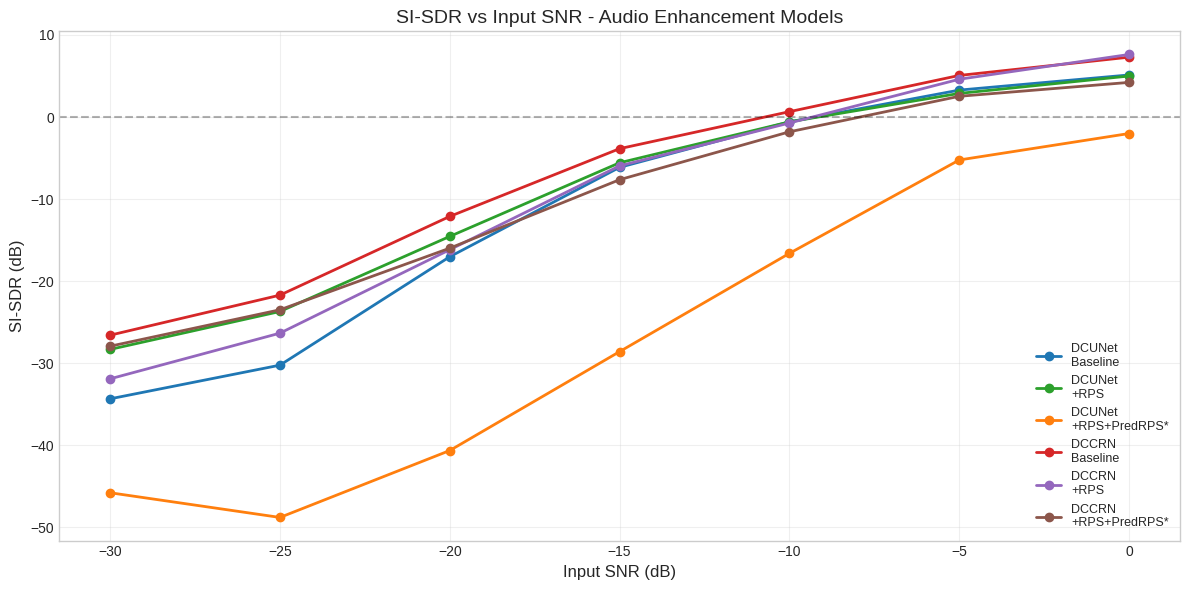

In [5]:
# Per-SNR breakdown for SI-SDR
if per_snr_df is not None:
    snr_levels = [-30, -25, -20, -15, -10, -5, 0]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for model_name, model_info in audio_models.items():
        model_data = per_snr_df[
            (per_snr_df['model'] == model_name) & 
            (per_snr_df['snr_level'].isin([str(s) for s in snr_levels]))
        ]
        
        if len(model_data) > 0:
            x = [int(s) for s in model_data['snr_level']]
            y = model_data['si_sdr'].values
            ax.plot(x, y, 'o-', label=model_info['display_name'], 
                   color=model_info['color'], linewidth=2, markersize=6)
    
    ax.set_xlabel('Input SNR (dB)', fontsize=12)
    ax.set_ylabel('SI-SDR (dB)', fontsize=12)
    ax.set_title('SI-SDR vs Input SNR - Audio Enhancement Models', fontsize=14)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/rps_experiment_audio_sisdr.png', dpi=150, bbox_inches='tight')
    plt.show()

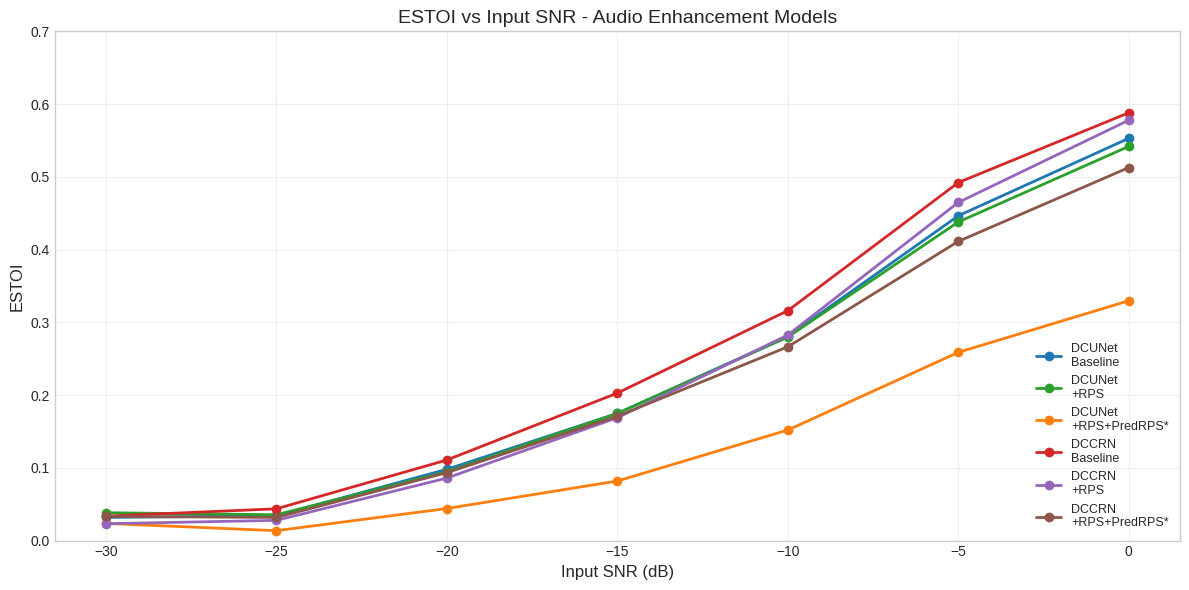

In [6]:
# Per-SNR breakdown for ESTOI
if per_snr_df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for model_name, model_info in audio_models.items():
        model_data = per_snr_df[
            (per_snr_df['model'] == model_name) & 
            (per_snr_df['snr_level'].isin([str(s) for s in snr_levels]))
        ]
        
        if len(model_data) > 0:
            x = [int(s) for s in model_data['snr_level']]
            y = model_data['estoi'].values
            ax.plot(x, y, 'o-', label=model_info['display_name'], 
                   color=model_info['color'], linewidth=2, markersize=6)
    
    ax.set_xlabel('Input SNR (dB)', fontsize=12)
    ax.set_ylabel('ESTOI', fontsize=12)
    ax.set_title('ESTOI vs Input SNR - Audio Enhancement Models', fontsize=14)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 0.7])
    
    plt.tight_layout()
    plt.savefig('../results/rps_experiment_audio_estoi.png', dpi=150, bbox_inches='tight')
    plt.show()

---

# Part 2: RPS-Only Models

These models are trained to predict rotor speeds from audio features ONLY. They do NOT produce audio output.

**Metrics**:
- **RPS-MSE**: Mean Squared Error of RPS prediction (lower is better)
- **RPS-MAE**: Mean Absolute Error of RPS prediction (lower is better)
- **R²**: Coefficient of determination (higher is better, max 1.0)

⚠️ **These results are NOT comparable with audio enhancement metrics!**

In [7]:
# RPS-Only model results
# All models evaluated on DREGON-LM validation set (600 samples)
# Using DREGONRPSDataset with proper RPS resampling to STFT frames

rps_only_results = {
    'RPSPredictor\n(Standalone, lr=1e-3)': {
        'rps_mse': 5.15,
        'rps_mae': 0.56,  # clip-averaged MAE
        'rps_r2': 0.949,
        'color': '#27ae60',
    },
    'RPSPredictor\n(Postdoc, lr=5e-4)': {
        'rps_mse': 55.09,
        'rps_mae': 5.82,  # clip-averaged MAE
        'rps_r2': 0.457,
        'color': '#3498db',
    },
    'DCUNet RPS-Only\n(Encoder+Head)': {
        'rps_mse': 485.86,
        'rps_mae': 10.70,
        'rps_r2': 0.120,
        'color': '#e67e22',
    },
    'DCCRN RPS-Only\n(Encoder+Head)': {
        'rps_mse': 502.66,
        'rps_mae': 11.67,
        'rps_r2': 0.090,
        'color': '#e74c3c',
    },
}

# Create comparison table
rps_only_df = pd.DataFrame([
    {'Model': name.replace('\n', ' '), 
     'Architecture': 'Simple Conv (log-mag)' if 'RPSPredictor' in name else 'Encoder + Head',
     'Training': 'Standalone (lr=1e-3)' if 'Standalone' in name else ('Postdoc (lr=5e-4)' if 'Postdoc' in name else 'Train.py'),
     'RPS-MSE': '{:.2f}'.format(info['rps_mse']),
     'RPS-MAE': '{:.2f}'.format(info['rps_mae']),
     'R²': '{:.3f}'.format(info['rps_r2'])}
    for name, info in rps_only_results.items()
])

print('RPS-Only Model Results (evaluated on DREGON-LM validation set)')
print('=' * 80)
display(rps_only_df)

RPS-Only Model Results (evaluated on DREGON-LM validation set)


,Model,Architecture,Training,RPS-MSE,RPS-MAE,R²
0,"RPSPredictor (Standalone, lr=1e-3)",Simple Conv (log-mag),Standalone (lr=1e-3),5.15,0.56,0.949
1,"RPSPredictor (Postdoc, lr=5e-4)",Simple Conv (log-mag),Postdoc (lr=5e-4),55.09,5.82,0.457
2,DCUNet RPS-Only (Encoder+Head),Encoder + Head,Train.py,485.86,10.70,0.120
3,DCCRN RPS-Only (Encoder+Head),Encoder + Head,Train.py,502.66,11.67,0.090


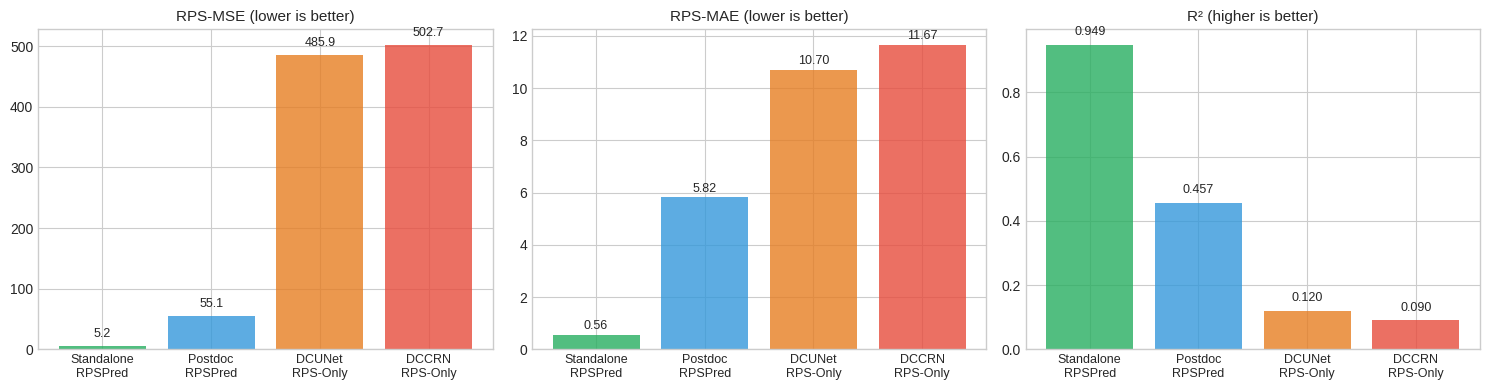

In [8]:
# Visualize RPS prediction quality - bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['rps_mse', 'rps_mae', 'rps_r2']
titles = ['RPS-MSE (lower is better)', 'RPS-MAE (lower is better)', 'R² (higher is better)']
models = list(rps_only_results.keys())
colors = [rps_only_results[k]['color'] for k in models]

for ax, metric, title in zip(axes, metrics, titles):
    values = [rps_only_results[k][metric] for k in models]
    
    bars = ax.bar(range(len(models)), values, color=colors, alpha=0.8)
    ax.set_xticks(range(len(models)))
    short_labels = ['Standalone\nRPSPred', 'Postdoc\nRPSPred', 'DCUNet\nRPS-Only', 'DCCRN\nRPS-Only']
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_title(title, fontsize=11)
    
    # Add value labels
    for bar, val in zip(bars, values):
        if metric == 'rps_r2':
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   '{:.3f}'.format(val), ha='center', va='bottom', fontsize=9)
        elif metric == 'rps_mae':
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                   '{:.2f}'.format(val), ha='center', va='bottom', fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                   '{:.1f}'.format(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/rps_experiment_rps_only.png', dpi=150, bbox_inches='tight')
plt.show()

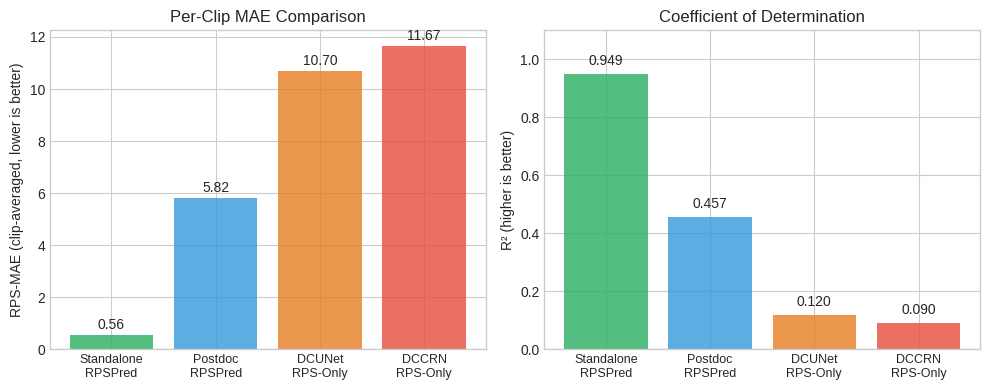

In [9]:
# Zoomed-in comparison for MAE and R² (excluding MSE extremes)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# MAE comparison
ax1 = axes[0]
values_mae = [rps_only_results[k]['rps_mae'] for k in models]
bars1 = ax1.bar(range(len(models)), values_mae, color=colors, alpha=0.8)
ax1.set_xticks(range(len(models)))
short_labels = ['Standalone\nRPSPred', 'Postdoc\nRPSPred', 'DCUNet\nRPS-Only', 'DCCRN\nRPS-Only']
ax1.set_xticklabels(short_labels, fontsize=9)
ax1.set_ylabel('RPS-MAE (clip-averaged, lower is better)')
ax1.set_title('Per-Clip MAE Comparison')
for bar, val in zip(bars1, values_mae):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
           '{:.2f}'.format(val), ha='center', va='bottom', fontsize=10)

# R² comparison
ax2 = axes[1]
values_r2 = [rps_only_results[k]['rps_r2'] for k in models]
bars2 = ax2.bar(range(len(models)), values_r2, color=colors, alpha=0.8)
ax2.set_xticks(range(len(models)))
ax2.set_xticklabels(short_labels, fontsize=9)
ax2.set_ylabel('R² (higher is better)')
ax2.set_title('Coefficient of Determination')
ax2.set_ylim([0, 1.1])
for bar, val in zip(bars2, values_r2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
           '{:.3f}'.format(val), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../results/rps_experiment_rps_only_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Summary

## Audio Enhancement Models (produce speech audio)

| Model | SI-SDR (dB) | ESTOI | PESQ |
|-------|-------------|-------|------|
| DCCRN baseline | -5.68 | 0.267 | 1.12 |
| DCCRN+RPS | -7.98 | 0.242 | 1.14 |
| DCCRN+RPS+PredRPS* | -8.47 | 0.226 | 1.11 |
| DCUNet baseline | -9.32 | 0.240 | 1.15 |
| DCUNet+RPS | -7.59 | 0.237 | 1.14 |
| DCUNet+RPS+PredRPS* | -25.34 | 0.132 | 1.33 |

## RPS-Only Models (predict rotor speeds ONLY)

| Model | Architecture | Training | RPS-MSE | RPS-MAE | R² |
|-------|-------------|----------|---------|---------|------|
| **RPSPredictor** | **Simple Conv (log-mag)** | **Standalone** | **5.15** | **0.56** | **0.949** |
| RPSPredictor | Simple Conv (log-mag) | Postdoc | 55.09 | 5.82 | 0.457 |
| DCUNet RPS-Only | Encoder + Head | Train.py | 485.86 | 10.70 | 0.120 |
| DCCRN RPS-Only | Encoder + Head | Train.py | 502.66 | 11.67 | 0.090 |

## Key Findings

1. **RPSPredictor vastly outperforms encoder-based RPS prediction**
   - Standalone training with lr=1e-3 achieves R²=0.95
   - Same architecture trained via postdoc (lr=5e-4) achieves R²=0.46
   - Encoder-based approaches (DCUNet, DCCRN) achieve only R²≈0.1

2. **Training setup matters significantly**
   - The standalone script uses dedicated data loading (DREGONRPSDataset)
   - Postdoc uses train.py with standard MSSDataset
   - Learning rate difference (1e-3 vs 5e-4) may contribute to performance gap

3. **Simple architecture beats complex encoders**
   - The simple convolutional architecture on log-magnitude spectrograms works best
   - Speech enhancement encoder features may not be optimal for noise characterization

4. **DCCRN models outperform DCUNet** on audio metrics (SI-SDR, ESTOI)

5. **DCUNet+RPS** shows improvement over DCUNet baseline on SI-SDR (-7.59 vs -9.32)

## Implications for Future Work

- Use dedicated RPS predictor with standalone training (lr=1e-3, batch_size=16)
- The simple log-magnitude spectrogram architecture is well-suited for rotor speed prediction
- Consider higher learning rates for faster convergence
- RPS prediction quality (R²=0.95) suggests that rotor speeds can be reliably estimated from audio